# IT Operations Dashboard - Testing

Input satu laporan secara manual, simpan ke CSV, lalu visualisasikan seluruh data tersimpan. Field mengikuti dua gambar yang diberikan.

In [10]:
from pathlib import Path
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA_DIR = Path('data'); DATA_DIR.mkdir(exist_ok=True)
CSV_PATH = DATA_DIR / 'it_operations_reports.csv'
AVAILABILITY_TARGET, SLA_TARGET = 99.50, 95.00
sns.set_theme(style='whitegrid', context='talk')
COLUMNS = ['report_period','department','report_id','report_date','generated_time','report_status','primary_application','supporting_server','supporting_system','reporting_cycle','application_availability','total_incidents','application_tickets','sla_compliance']

## 1. Input manual - satu laporan

Jalankan cell berikut dan isi setiap field dari satu PDF report. Persentase diisi tanpa `%`. Ketik `batal` pada field pertama jika ingin melewati input dan hanya membuka data/chart yang sudah ada.

In [11]:
def ask_text(label):
    while not (value := input(f'{label}: ').strip()):
        print('Nilai wajib diisi.')
    return value

def ask_number(label, integer=False, maximum=None):
    while True:
        try:
            value = float(input(f'{label}: ').strip().replace('%', '').replace(',', '.'))
            if value < 0 or (maximum is not None and value > maximum): raise ValueError
            return int(value) if integer else value
        except ValueError:
            print('Masukkan angka valid.')

period = input('Report Period (contoh: January 2026, atau batal): ').strip()
if period.lower() != 'batal':
    record = {
        'report_period': period, 'department': ask_text('Department'), 'report_id': ask_text('Report ID'),
        'report_date': ask_text('Report Date (DD Month YYYY)'), 'generated_time': ask_text('Generated Time'),
        'report_status': ask_text('Report Status'), 'primary_application': ask_text('Primary Application'),
        'supporting_server': ask_text('Supporting Server'), 'supporting_system': ask_text('Supporting System'),
        'reporting_cycle': ask_text('Reporting Cycle'),
        'application_availability': ask_number('Application Availability (%)', maximum=100),
        'total_incidents': ask_number('Total Incidents', integer=True),
        'application_tickets': ask_number('Application Tickets', integer=True),
        'sla_compliance': ask_number('SLA Compliance (%)', maximum=100)
    }
    datetime.strptime(record['report_date'], '%d %B %Y')
    existing = pd.read_csv(CSV_PATH) if CSV_PATH.exists() else pd.DataFrame(columns=COLUMNS)
    if record['report_id'] in existing['report_id'].astype(str).tolist():
        raise ValueError('Report ID sudah ada; gunakan ID unik agar data tidak duplikat.')
    pd.concat([existing, pd.DataFrame([record], columns=COLUMNS)], ignore_index=True).to_csv(CSV_PATH, index=False)
    print(f"Data berhasil ditambahkan ke: {CSV_PATH.resolve()}")
else:
    print('Input dibatalkan; CSV tidak berubah.')

Data berhasil ditambahkan ke: C:\Users\22931567\anaconda3\envs\Pythones\Projects\Tracker_App\data\it_operations_reports.csv


## 2. Muat total data dari CSV

In [12]:
if not CSV_PATH.exists(): raise FileNotFoundError('Belum ada CSV. Masukkan minimal satu laporan terlebih dahulu.')
data = pd.read_csv(CSV_PATH)
if data.empty: raise ValueError('CSV kosong.')
number_cols = ['application_availability','total_incidents','application_tickets','sla_compliance']
data[number_cols] = data[number_cols].apply(pd.to_numeric, errors='raise')
data['report_date'] = pd.to_datetime(data['report_date'], format='%d %B %Y')
data = data.sort_values(['report_date','primary_application'])
print(f"{len(data)} laporan | {data['primary_application'].nunique()} aplikasi")
display(data)

2 laporan | 2 aplikasi


,report_period,department,report_id,report_date,generated_time,report_status,primary_application,supporting_server,supporting_system,reporting_cycle,application_availability,total_incidents,application_tickets,sla_compliance
1,January 2026,IT Operations,ITOPS-MON-2026-01-063,2026-01-09,16:47 WIB,Final,Atlas Workflow Console,Vespera Integration Node,Nimbus Notification Gateway,Monthly,98.94,16,128,93.8
0,Januari 2026,IT Operations,ITOPS-MON-2026-01-119,2026-01-09,08:26 WIB,Final,Orion Identity Hub,Solstice Authentication Node,Cobalt Access & Notification System,Monthly,99.73,167,96,10.0


## 3. Ringkasan manajemen

In [13]:
summary = pd.DataFrame({'Indikator':['Jumlah laporan','Jumlah aplikasi','Rata-rata availability','Rata-rata SLA','Total insiden','Total tiket'], 'Nilai':[len(data), data.primary_application.nunique(), f"{data.application_availability.mean():.2f}%", f"{data.sla_compliance.mean():.2f}%", int(data.total_incidents.sum()), int(data.application_tickets.sum())]})
display(summary)

,Indikator,Nilai
0,Jumlah laporan,2
1,Jumlah aplikasi,2
2,Rata-rata availability,99.34%
3,Rata-rata SLA,51.90%
4,Total insiden,183
5,Total tiket,224


## 4. Chart: Application Availability per aplikasi
Merah = di bawah target 99.50%.

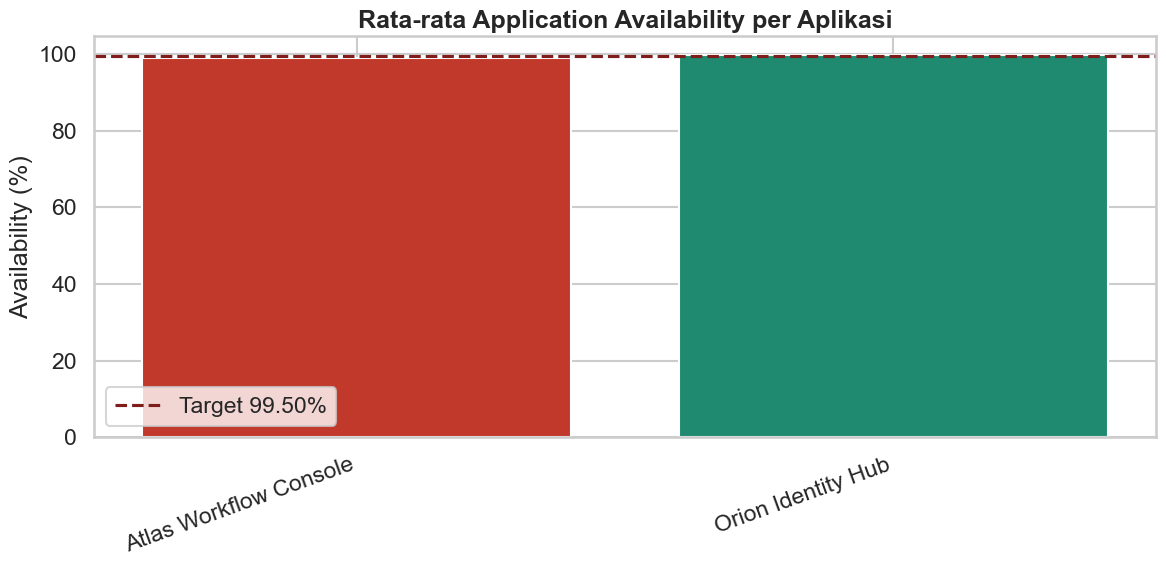

In [14]:
chart = data.groupby('primary_application',as_index=False).application_availability.mean().sort_values('application_availability')
plt.figure(figsize=(12,6)); plt.bar(chart.primary_application,chart.application_availability,color=['#c0392b' if x < AVAILABILITY_TARGET else '#1f8a70' for x in chart.application_availability]); plt.axhline(AVAILABILITY_TARGET,color='#7f1d1d',linestyle='--',label='Target 99.50%'); plt.title('Rata-rata Application Availability per Aplikasi',fontweight='bold'); plt.ylabel('Availability (%)'); plt.xticks(rotation=20,ha='right'); plt.legend(); plt.tight_layout(); plt.show()

## 5. Chart: Total insiden per aplikasi

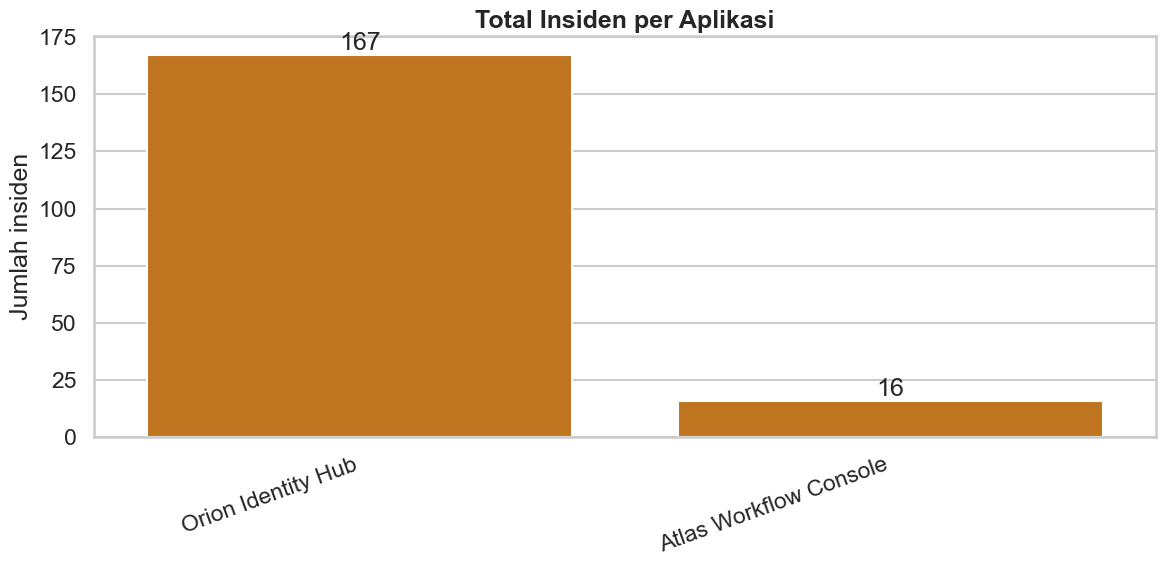

In [15]:
chart = data.groupby('primary_application',as_index=False).total_incidents.sum().sort_values('total_incidents',ascending=False)
plt.figure(figsize=(12,6)); ax=sns.barplot(data=chart,x='primary_application',y='total_incidents',color='#d97706'); ax.bar_label(ax.containers[0]); plt.title('Total Insiden per Aplikasi',fontweight='bold'); plt.xlabel(''); plt.ylabel('Jumlah insiden'); plt.xticks(rotation=20,ha='right'); plt.tight_layout(); plt.show()

## 6. Chart: Total application tickets per aplikasi

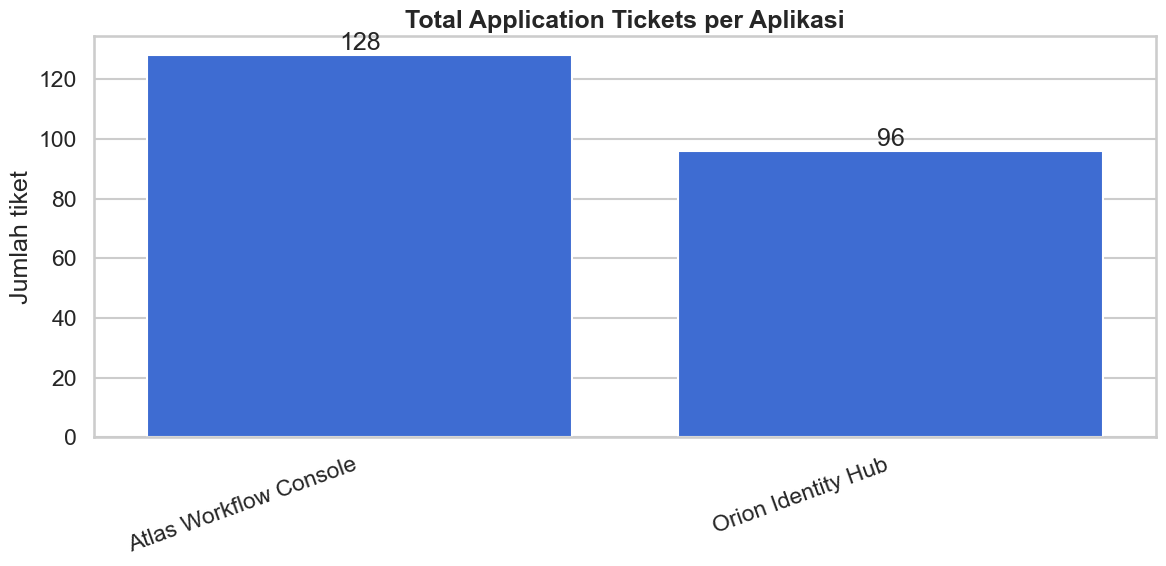

In [16]:
chart = data.groupby('primary_application',as_index=False).application_tickets.sum().sort_values('application_tickets',ascending=False)
plt.figure(figsize=(12,6)); ax=sns.barplot(data=chart,x='primary_application',y='application_tickets',color='#2563eb'); ax.bar_label(ax.containers[0]); plt.title('Total Application Tickets per Aplikasi',fontweight='bold'); plt.xlabel(''); plt.ylabel('Jumlah tiket'); plt.xticks(rotation=20,ha='right'); plt.tight_layout(); plt.show()

## 7. Chart: SLA Compliance per aplikasi
Merah = di bawah target 95%.

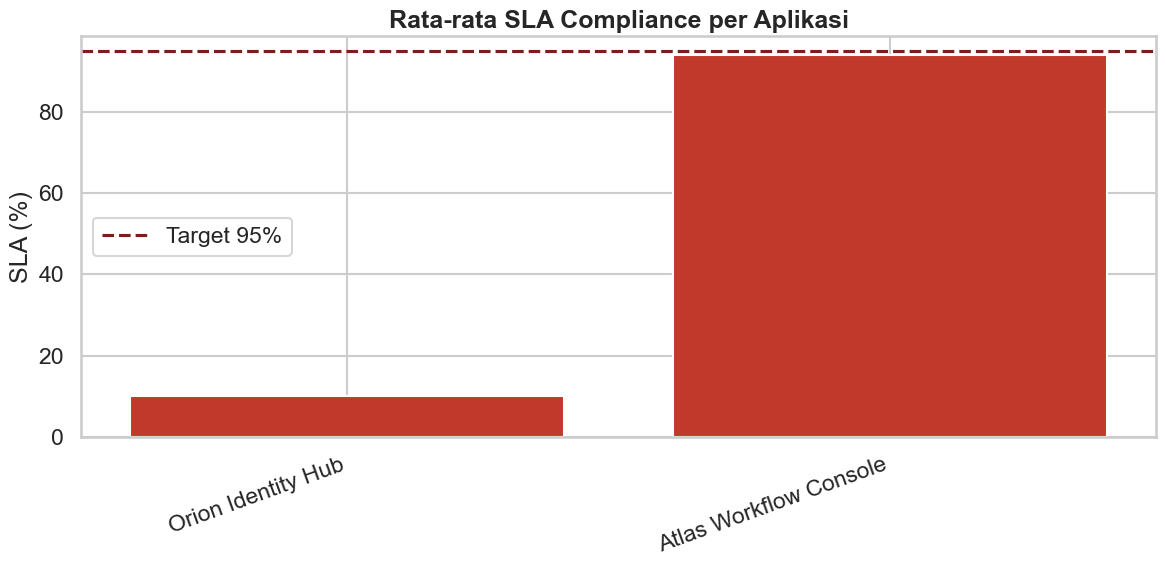

In [17]:
chart = data.groupby('primary_application',as_index=False).sla_compliance.mean().sort_values('sla_compliance')
plt.figure(figsize=(12,6)); plt.bar(chart.primary_application,chart.sla_compliance,color=['#c0392b' if x < SLA_TARGET else '#1f8a70' for x in chart.sla_compliance]); plt.axhline(SLA_TARGET,color='#7f1d1d',linestyle='--',label='Target 95%'); plt.title('Rata-rata SLA Compliance per Aplikasi',fontweight='bold'); plt.ylabel('SLA (%)'); plt.xticks(rotation=20,ha='right'); plt.legend(); plt.tight_layout(); plt.show()

## 8. Chart: Tren availability seluruh aplikasi per periode
Bermanfaat ketika data sudah mencakup lebih dari satu periode.

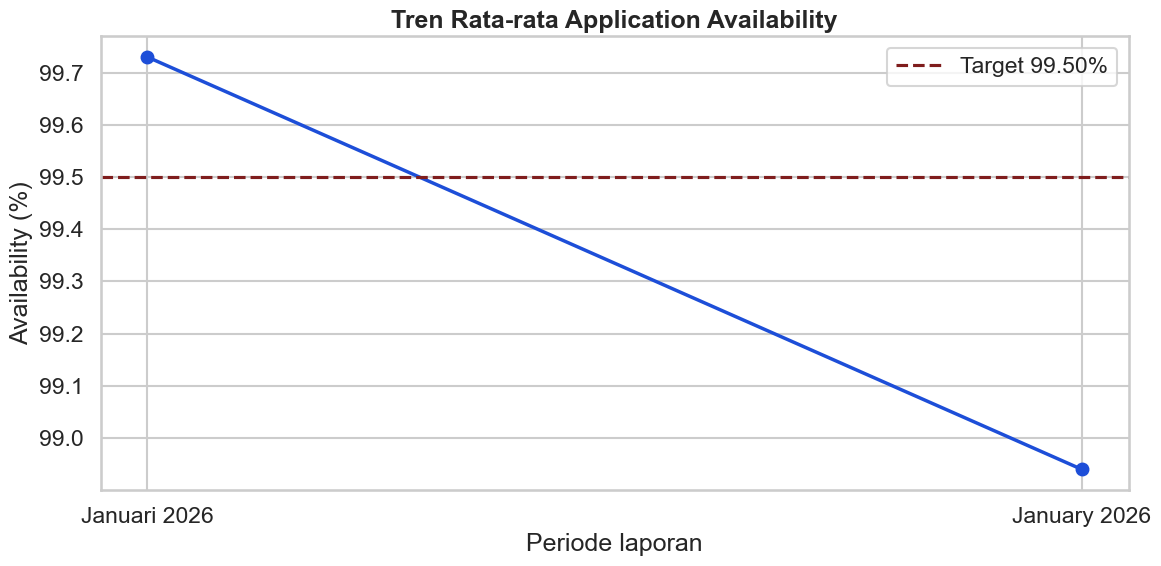

In [18]:
chart = data.groupby(['report_date','report_period'],as_index=False).application_availability.mean().sort_values('report_date')
plt.figure(figsize=(12,6)); plt.plot(chart.report_period,chart.application_availability,marker='o',linewidth=2.5,color='#1d4ed8'); plt.axhline(AVAILABILITY_TARGET,color='#7f1d1d',linestyle='--',label='Target 99.50%'); plt.title('Tren Rata-rata Application Availability',fontweight='bold'); plt.ylabel('Availability (%)'); plt.xlabel('Periode laporan'); plt.legend(); plt.tight_layout(); plt.show()